# Raster data

Companion notebook to deck **02 — A Practical Guide to Spatial Data**
(section *Raster Data*). It reproduces the deck's worked examples and numbers
with `rasterio` and `rioxarray`: read a GeoTIFF and its metadata, take a windowed
read, reproject, and finish with the **zonal-statistics** recipe (mask by
geometry, then reduce).

The dataset is the bundled **GHSL São Paulo** population-grid raster
(`data/ghsl/ghsl_sao_paulo.tif`), a single float32 band on a 250 m grid.

In [1]:
# Imports and environment check
import warnings
warnings.filterwarnings("ignore")  # keep the lesson output clean

import os
import numpy as np
import rasterio
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt

print("rasterio  ", rasterio.__version__)
print("rioxarray ", rioxarray.__version__)

ras_path = "data/ghsl/ghsl_sao_paulo.tif"

rasterio   1.5.0
rioxarray  0.19.0


## Read a raster and inspect its metadata

`rasterio` is the GDAL-backed library for reading and writing raster files,
exposing the affine transform, CRS, `nodata` value, and band metadata. Always
open inside a `with rasterio.open(...) as src:` block so the file handle closes
cleanly.

In [2]:
with rasterio.open(ras_path) as src:
    print("crs:   ", src.crs)
    print("size:  ", src.width, "x", src.height)
    print("bands: ", src.count)
    print("dtype: ", src.dtypes[0])
    print("res:   ", src.res)
    print("nodata:", src.nodata)
    print("bounds:", src.bounds)
    arr = src.read(1)
    print("band 1 min/max:", float(arr.min()), float(arr.max()))

crs:    ESRI:54009
size:   468 x 416
bands:  1
dtype:  float32
res:    (250.0, 250.0)
nodata: -200.0
bounds: BoundingBox(left=-4482000.0, bottom=-2926000.0, right=-4365000.0, top=-2822000.0)
band 1 min/max: -200.0 6563.03662109375


One float32 band, `468 x 416` cells at **250 m** resolution, projected in the
World Mollweide equal-area CRS (`ESRI:54009`) with `nodata = -200`. That `nodata`
code is why the raw `min` looks extreme — we must mask it before any statistic.

> **Lesson —** read the CRS, resolution, and `nodata` *before* touching pixel
> values; the `nodata` code will poison any statistic if you leave it in.

## Plot with `rioxarray`

`rioxarray` combines Rasterio with `xarray`: labeled N-dimensional arrays with a
CRS and a `.rio` accessor. Opening with `masked=True` turns `nodata` into `NaN`
automatically, so the plot shows only valid pixels.

ESRI:54009 (1, 416, 468)


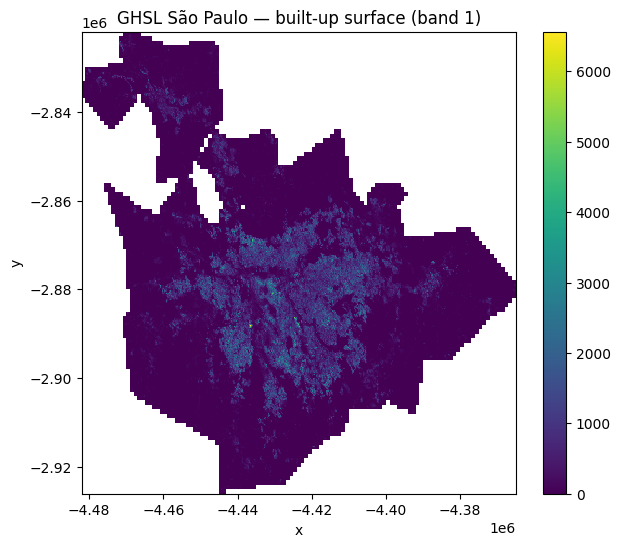

In [3]:
rds = rioxarray.open_rasterio(ras_path, masked=True)
print(rds.rio.crs, rds.shape)

rds.sel(band=1).plot(figsize=(7, 6), cmap="viridis")
plt.title("GHSL São Paulo — built-up surface (band 1)")
plt.show()

The dense built-up core stands out against the surrounding grid — a continuous
field sampled on cells, the defining shape of raster data.

## Windowed read

Rasterio supports **windowed** reads, so analysis can load only the required
pixels instead of the whole grid — essential for rasters too large to fit in
memory. A `Window(col_off, row_off, width, height)` clips to the dataset extent.

In [4]:
from rasterio.windows import Window

with rasterio.open(ras_path) as src:
    window = Window(0, 0, 512, 512)
    arr = src.read(1, window=window)
    print("window array shape:", arr.shape)
    print("pixel size:", src.res)

window array shape: (416, 468)
pixel size: (250.0, 250.0)


We asked for a 512×512 window, but the raster is only 468×416, so the read clips
to `(416, 468)` — the available pixels — without error.

> **Lesson —** windowed reads load only the pixels you ask for (clipped to the
> grid), so a small analysis never has to pull the whole raster into memory.

## Reproject with `rioxarray`

`rioxarray` simplifies raster reprojection by handling the warping for you: the
`.rio.reproject(...)` accessor resamples the grid into the target CRS. We move the
raster to Web Mercator (`EPSG:3857`) and write it back out.

In [5]:
os.makedirs("outputs", exist_ok=True)

rds = rioxarray.open_rasterio(ras_path)
rds_3857 = rds.rio.reproject("EPSG:3857")
print("Reprojected CRS:", rds_3857.rio.crs)
print("New grid shape: ", rds_3857.shape)
rds_3857.rio.to_raster("outputs/ghsl_sao_paulo_3857.tif")

Reprojected CRS: EPSG:3857
New grid shape:  (1, 422, 632)


Warping to `EPSG:3857` resamples the grid (the shape changes because the pixels
are re-laid on a new coordinate frame). `EPSG:3857` is a display CRS — reproject
for tiles, but measure areas in the equal-area source grid.

> **Lesson —** raster reprojection *resamples* — the grid is rebuilt on the new
> CRS, so pixel count and alignment change; choose the resampler to match the data.

## Resampling: match the method to the data

Reprojection and rescaling both **resample** — they interpolate new cell values.
The method must match the data semantics:

- **Nearest** — categorical labels (land cover, class maps); never invents
  intermediate classes.
- **Bilinear / cubic** — continuous surfaces (elevation, reflectance); smoother
  results.
- **Sum / average** — extensive quantities (population counts) where totals must
  be conserved on aggregation.

> **Lesson —** resampling silently rewrites your values — pick nearest for
> categories, bilinear/cubic for continuous fields, sum/average to conserve totals.

## Raster alignment and resolution

Raster analysis compares cells. Two rasters can share a CRS and still be
incompatible if their grids do not align — different resolution, extent, or
origin means each cell covers a different patch of ground. Align one raster to
another with `reproject_match` before subtraction, ratios, masking, or model
inputs.

> **Lesson —** before any cell-by-cell raster math, align grids with
> `reproject_match`; a shared CRS alone does not guarantee the cells line up.

## Raster Recipe: masking and zonal statistics

The zonal-statistics pattern computes one number per polygon from the pixels it
covers: **mask by geometry, then reduce**. No bundled vector overlaps the GHSL
São Paulo raster, so we split the raster's *own extent* into West/East test
halves — guaranteed to intersect it — and take the mean built-up value in each.
The polygons inherit the raster CRS so the mask stays in the grid's coordinate
system.

In [6]:
from rasterio.mask import mask
from shapely.geometry import box

with rasterio.open(ras_path) as src:
    # West/East halves of the raster's extent (guaranteed to overlap)
    left, bottom, right, top = src.bounds
    mx = (left + right) / 2
    cells = {"W": box(left, bottom, mx, top),
             "E": box(mx, bottom, right, top)}
    polygons = gpd.GeoDataFrame(
        {"name": list(cells)}, geometry=list(cells.values()), crs=src.crs)

    # The loop stays INSIDE the with-block so src is still open while masking
    results = []
    for geom in polygons.geometry:
        out_image, _ = mask(src, [geom], crop=True)
        arr = out_image.astype("float32")
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
        mean_val = np.nanmean(arr)
        results.append(float(mean_val) if np.isfinite(mean_val) else None)

    polygons["mean_raster_value"] = results

print(polygons[["name", "mean_raster_value"]].round(2))

  name  mean_raster_value
0    W             210.10
1    E             243.21


`mask` clips the raster to each polygon; `nanmean` reduces the valid pixels to one
number per feature:

| name | mean_raster_value |
|---|---|
| W | 210.10 |
| E | 243.21 |

The eastern half has the higher mean built-up value. Masking the `nodata` cells
to `NaN` first is what makes these means trustworthy.

> **Lesson —** zonal statistics = mask by geometry, then reduce (mean / sum / …):
> the bridge from a pixel grid to one value per vector feature.

## Visualize the zones

Overlaying the two test polygons on the raster shows exactly which pixels feed
each mean — the visual check that the mask did what we intended.

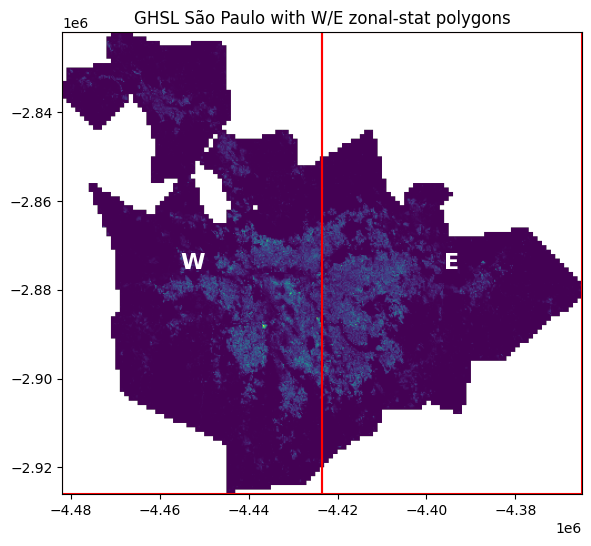

In [7]:
from rasterio.plot import show

with rasterio.open(ras_path) as src:
    fig, ax = plt.subplots(figsize=(7, 6))
    show(src.read(1, masked=True), transform=src.transform,
         cmap="viridis", ax=ax)
    polygons.boundary.plot(ax=ax, edgecolor="red", linewidth=1.5)
    for _, r in polygons.iterrows():
        c = r.geometry.centroid
        ax.text(c.x, c.y, r["name"], color="white", fontsize=16,
                ha="center", va="center", fontweight="bold")
    ax.set_title("GHSL São Paulo with W/E zonal-stat polygons")
    plt.show()

Each red rectangle is one zone; the mean in the recipe above is simply the average
of the viridis pixels inside it.

> **Lesson —** always overlay the zones on the raster before trusting zonal
> statistics — a mis-projected polygon would sample the wrong pixels invisibly.

## Summary

- **Inspect CRS, resolution, and `nodata`** on open; mask `nodata` before any
  statistic.
- **Windowed reads** load only the pixels you need; **reprojection resamples**,
  so choose the resampler by data type.
- **Align grids** with `reproject_match` before cell-by-cell math.
- **Zonal statistics** = mask by geometry, then reduce — the pixel-grid → vector
  bridge (GHSL São Paulo W = 210.10, E = 243.21).

Deck **02** covers the concepts; the vector companion
(`00_vector_data.ipynb`) handles the polygon side of the same workflow.